In [971]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import *
from random import seed
from scipy import stats
import seaborn as sns
import pingouin as pg
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
import statsmodels.api as sm
from statsmodels.stats.api import anova_lm
from statsmodels.formula.api import ols
from statsmodels.regression import linear_model
from sklearn.metrics import explained_variance_score
from sklearn.linear_model import LassoCV, RidgeCV, Lasso
import matplotlib.cm as cm
%matplotlib inline

seed(888)
pd.set_option('display.max_columns', None)

# 1 Load data from "2 BrainAge"

In [972]:
# load data from pickle and convert to dataframe
# brain_test = pd.read_pickle("2_brain_test.pkl")
# brain_train = pd.read_pickle("2_brain_train.pkl")
main_test = pd.read_pickle("2_main_test.pkl")
main_train = pd.read_pickle("2_main_train.pkl")
# brain_test = pd.DataFrame(brain_test)
# brain_train = pd.DataFrame(brain_train)
main_test = pd.DataFrame(main_test)
main_train = pd.DataFrame(main_train)

# 2 Basic distributions

## 2.1 Data and Descriptives

In [973]:
main_test.head()

,ID,Age,Gender,TPA,VPA,MPA,MVPA,LPA,BMI,SRLPA,SRMPA,SRVPA,FI,HG,IS,HR,JPA,DBP,SBP,BADA2009,BADASEG,BADDesikan
10,1001365,71.0,Female,3396.9600,20.1600,514.0800,554.4000,2862.7200,28.2030,594.0,240.0,240.0,5.0,20.0,11025,73.0,NaN,70.0,106.0,-3.368359,-5.778844,1.426206
17,1001748,48.0,Female,3126.8160,265.3056,596.9376,1127.5488,2264.5728,25.7857,462.0,0.0,2400.0,8.0,34.0,11025,52.0,NaN,75.0,124.0,4.436540,-2.597256,-4.019098
20,1001984,69.0,Female,2468.4192,9.9936,579.6288,599.6160,1878.7968,25.7422,693.0,960.0,0.0,7.0,26.0,11026,76.0,NaN,79.0,120.0,1.578984,-3.924211,3.956300
21,1002138,56.0,Female,2465.2224,29.1168,427.0464,485.2800,2009.0592,33.5680,2970.0,720.0,240.0,NaN,18.0,11025,56.0,Sometimes,75.0,134.0,-4.514084,-11.725981,18.198585
23,1002288,63.0,Female,2559.7728,109.1376,704.4336,922.7088,1746.2016,27.4762,264.0,960.0,0.0,5.0,30.0,11025,85.0,NaN,84.0,146.0,-4.875772,-4.370042,14.883579


In [974]:
before = main_test.shape[0]
outlier = np.mean(main_test["SRLPA"]) + np.std(main_test["SRLPA"])*3
main_test = main_test[main_test["SRLPA"]<outlier]
outlier = np.mean(main_test["SRMPA"]) + np.std(main_test["SRMPA"])*3
main_test = main_test[main_test["SRMPA"]<outlier]
outlier = np.mean(main_test["SRVPA"]) + np.std(main_test["SRVPA"])*3
main_test = main_test[main_test["SRVPA"]<outlier]
after = main_test.shape[0]
print("Outliers on self-reported PA:", before-after)
print(after)

Outliers on self-reported PA: 563
5422


### 2.1.1 Test set

In [975]:
female = main_test[main_test["Gender"] == "Female"]
male = main_test[main_test["Gender"]== "Male"]

print("Number of females:", female.shape[0])
print("NUmber of males:",male.shape[0])

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("LPA")
mean = female["LPA"].mean()
print("Female", mean)
std = female["LPA"].std()
print("Female",std)
mean = male["LPA"].mean()
print("Male",mean)
std = male["LPA"].std()
print("Male",std)

print("MPA")
mean = female["MPA"].mean()
print("Female", mean)
std = female["MPA"].std()
print("Female",std)
mean = male["MPA"].mean()
print("Male",mean)
std = male["MPA"].std()
print("Male",std)

print("VPA")
mean = female["VPA"].mean()
print("Female", mean)
std = female["VPA"].std()
print("Female",std)
mean = male["VPA"].mean()
print("Male",mean)
std = male["VPA"].std()
print("Male",std)

print("TPA")
mean = female["TPA"].mean()
print("Female", mean)
std = female["TPA"].std()
print("Female",std)
mean = male["TPA"].mean()
print("Male",mean)
std = male["TPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("FI")
mean = female["FI"].mean()
print("Female", mean)
std = female["FI"].std()
print("Female",std)
mean = male["FI"].mean()
print("Male",mean)
std = male["FI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

Number of females: 2898
NUmber of males: 2524
Age
Female 63.49482401656315
Female 7.556813291182583
Male 65.49207606973059
Male 7.824543474679913
LPA
Female 2056.1930434782607
Female 406.8644273491336
Male 1885.7437103011096
Male 405.84204331256376
MPA
Female 498.95904596273294
Female 226.04598507597225
Male 467.3088513470682
Male 219.2158898210811
VPA
Female 31.376486956521767
Female 41.49015419937569
Male 36.690498256735374
Male 47.658656646516
TPA
Female 2586.5285763975157
Female 549.9034889901462
Male 2389.743059904913
Male 544.1004962557213
BMI
Female 25.811531090407172
Female 4.5080781213825105
Male 26.943885657686213
Male 3.8018138925908085
HG
Female 26.233954451345756
Female 6.490942652213226
Male 42.08320126782884
Male 8.649252170729214
HR
Female 69.11076604554866
Female 10.061554495925744
Male 66.68621236133121
Male 11.241229111720902
SRLPA
Female 788.5644927536232
Female 716.9490442462906
Male 753.3099841521395
Male 709.4481511450006
SRMPA
Female 658.1545893719807
Female 770

### 2.1.2 Train set

In [976]:
female = main_train[main_train["Gender"] == "Female"]
male = main_train[main_train["Gender"]== "Male"]

print(female.shape)
print(male.shape)

print("Age")
mean = female["Age"].mean()
print("Female", mean)
std = female["Age"].std()
print("Female",std)
mean = male["Age"].mean()
print("Male",mean)
std = male["Age"].std()
print("Male",std)

print("SRLPA")
mean = female["SRLPA"].mean()
print("Female", mean)
std = female["SRLPA"].std()
print("Female",std)
mean = male["SRLPA"].mean()
print("Male",mean)
std = male["SRLPA"].std()
print("Male",std)

print("SRMPA")
mean = female["SRMPA"].mean()
print("Female", mean)
std = female["SRMPA"].std()
print("Female",std)
mean = male["SRMPA"].mean()
print("Male",mean)
std = male["SRMPA"].std()
print("Male",std)

print("SRVPA")
mean = female["SRVPA"].mean()
print("Female", mean)
std = female["SRVPA"].std()
print("Female",std)
mean = male["SRVPA"].mean()
print("Male",mean)
std = male["SRVPA"].std()
print("Male",std)

print("BMI")
mean = female["BMI"].mean()
print("Female", mean)
std = female["BMI"].std()
print("Female",std)
mean = male["BMI"].mean()
print("Male",mean)
std = male["BMI"].std()
print("Male",std)

print("FI")
mean = female["FI"].mean()
print("Female", mean)
std = female["FI"].std()
print("Female",std)
mean = male["FI"].mean()
print("Male",mean)
std = male["FI"].std()
print("Male",std)

print("DBP")
mean = female["DBP"].mean()
print("Female", mean)
std = female["DBP"].std()
print("Female",std)
mean = male["DBP"].mean()
print("Male",mean)
std = male["DBP"].std()
print("Male",std)

print("SBP")
mean = female["SBP"].mean()
print("Female", mean)
std = female["SBP"].std()
print("Female",std)
mean = male["SBP"].mean()
print("Male",mean)
std = male["SBP"].std()
print("Male",std)

print("HG")
mean = female["HG"].mean()
print("Female", mean)
std = female["HG"].std()
print("Female",std)
mean = male["HG"].mean()
print("Male",mean)
std = male["HG"].std()
print("Male",std)

print("HR")
mean = female["HR"].mean()
print("Female", mean)
std = female["HR"].std()
print("Female",std)
mean = male["HR"].mean()
print("Male",mean)
std = male["HR"].std()
print("Male",std)

(11117, 14)
(10325, 14)
Age
Female 63.836196815687686
Female 7.503871583194821
Male 65.00474576271186
Male 7.7586035249436
SRLPA
Female 984.1847981520185
Female 1033.3820726927277
Male 928.3805084745763
Male 1007.0754562865242
SRMPA
Female 837.8537014629853
Female 1113.6645965459636
Male 817.7301342725071
Male 1131.3713559199134
SRVPA
Female 574.130018699813
Female 920.1960026012333
Male 741.4853620955316
Male 1148.5582239428738
BMI
Female 26.138465982351878
Female 4.582669799430477
Male 27.191944284882588
Male 3.7562568482626655
FI
Female 6.54498191681736
Female 1.9884955462150418
Male 6.78415439309294
Male 2.0684582399719234
DBP
Female 79.32254626489681
Female 10.228206380591313
Male 83.40178664173678
Male 10.089943983473264
SBP
Female 132.82763298130027
Female 19.06073106946566
Male 140.33489145112705
Male 17.42547072290952
HG
Female 25.921382796281254
Female 6.415775125843123
Male 42.48262473306154
Male 8.766859109259675
HR
Female 69.22216839453542
Female 10.393253848960265
Male 66

## 2.3 Age and BrainAge

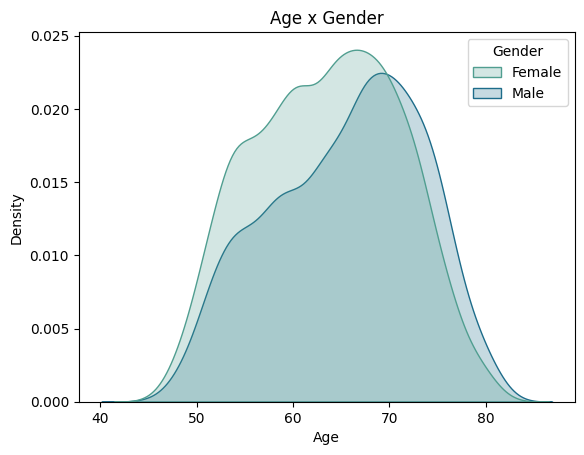

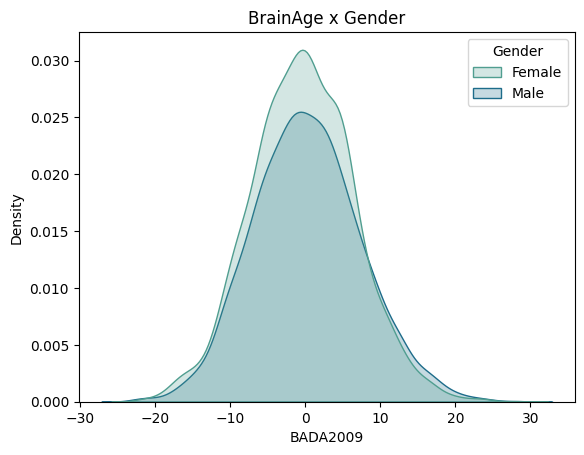

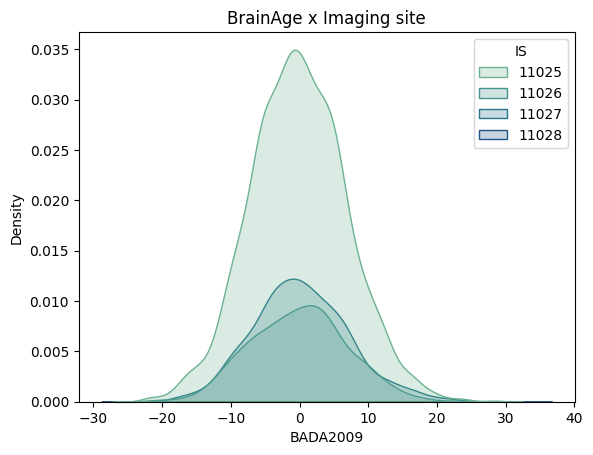

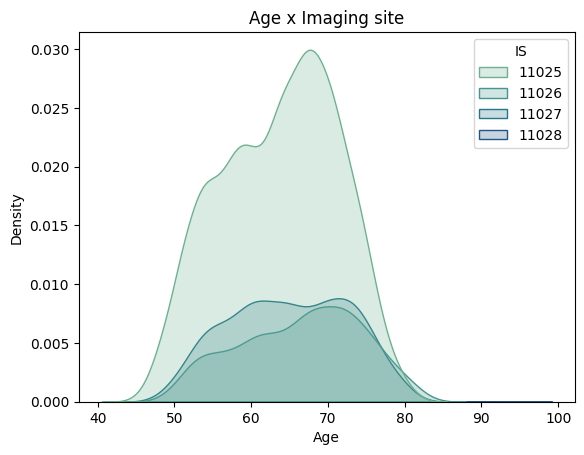

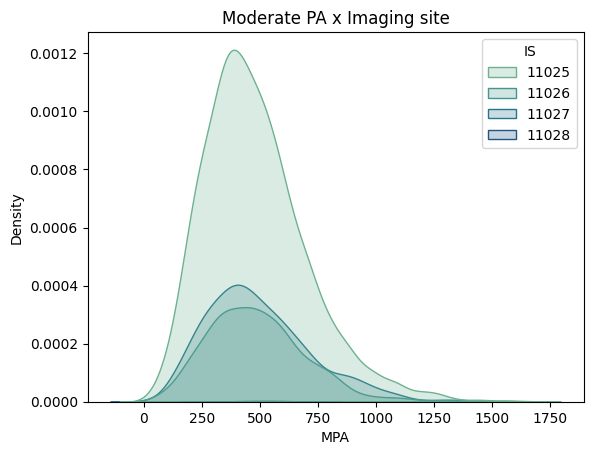

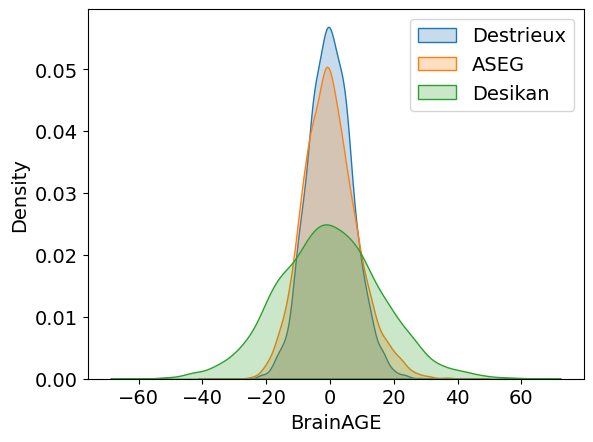

In [977]:
plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'Gender', fill=True, palette = "crest")
plt.title("Age x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'Gender', fill=True, palette = "crest")
plt.title("BrainAge x Gender")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', hue = 'IS', fill=True, palette = "crest")
plt.title("BrainAge x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'Age', hue = 'IS', fill=True, palette = "crest")
plt.title("Age x Imaging site")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'MPA', hue = 'IS', fill=True, palette = "crest")
plt.title("Moderate PA x Imaging site")
plt.show()


plt.figure()
sns.kdeplot(data = main_test, x= 'BADA2009', fill=True, label="Destrieux")
sns.kdeplot(data = main_test, x= 'BADASEG', fill=True, label="ASEG")
sns.kdeplot(data = main_test, x= 'BADDesikan', fill=True, label="Desikan")
#plt.title("BrainAge Segmentations")
plt.xlabel("BrainAGE", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()

## 2.4 Physical activity

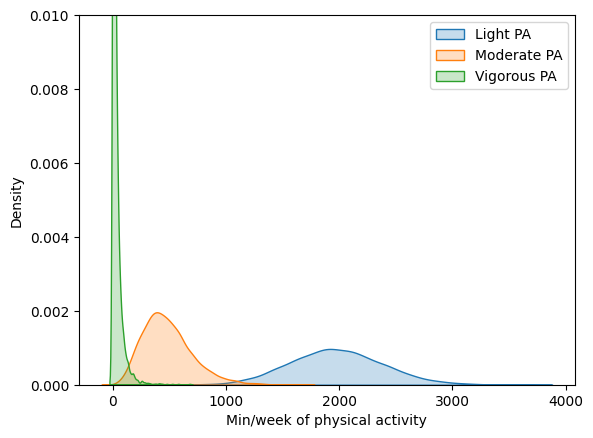

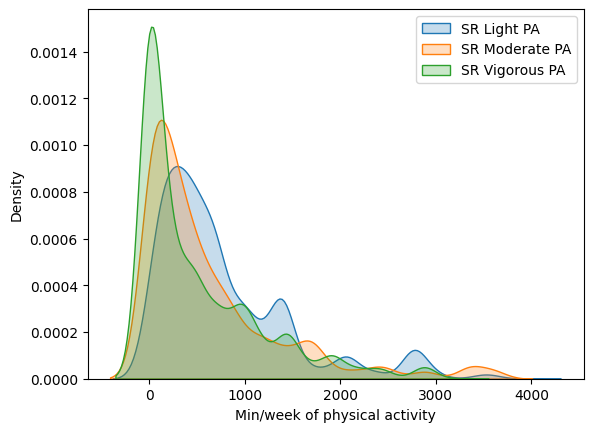

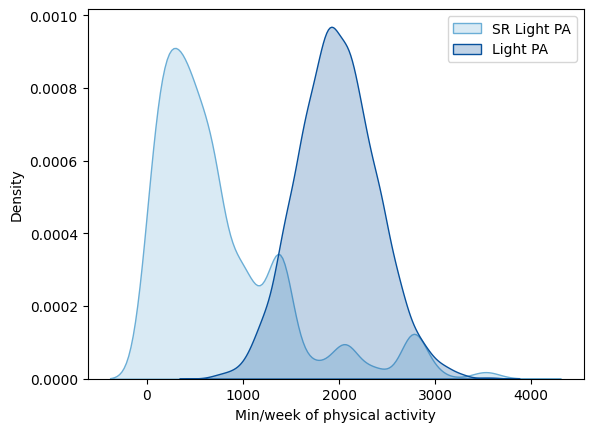

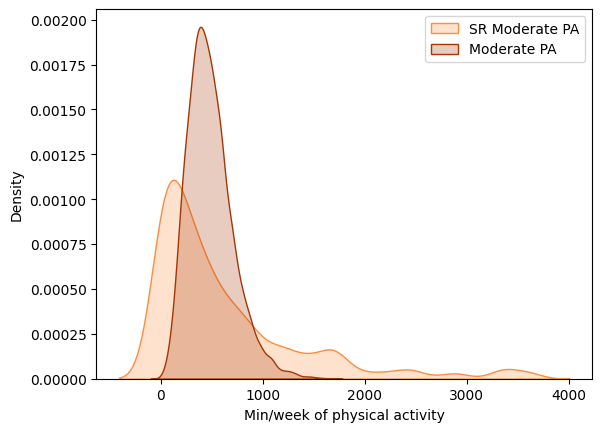

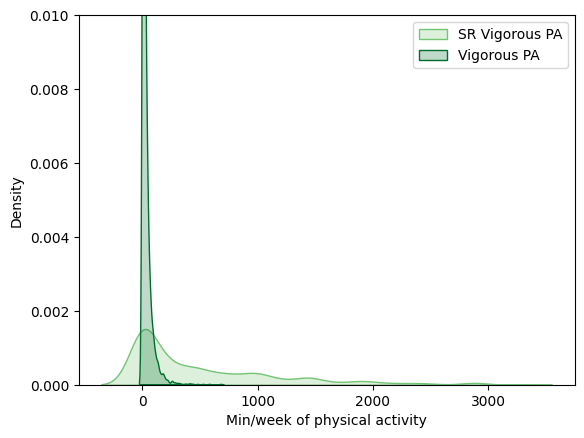

In [978]:
plt.figure()
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA")
#sns.kdeplot(data = main_test, x= 'TPA', fill=True, label = "Total PA")
plt.xlabel("Min/week of physical activity")
plt.legend()
plt.xticks(range(0,5000,1000))
plt.ylim(0,0.01)
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA")
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA")
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA")
plt.xlabel("Min/week of physical activity")
#plt.title("Self Report PA distributions")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRLPA', fill=True, label = "SR Light PA", color="#6baed6")
sns.kdeplot(data = main_test, x= 'LPA', fill=True, label = "Light PA", color="#08519c")
plt.xlabel("Min/week of physical activity")
#plt.title("SR vs. Accelerometry Light PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRMPA', fill=True, label = "SR Moderate PA", color="#fd8d3c")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Moderate PA", color="#a63603")
plt.xlabel("Min/week of physical activity")
#plt.title("SR vs. Accelerometry Moderate PA")
plt.legend()
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SRVPA', fill=True, label = "SR Vigorous PA", color="#74c476")
sns.kdeplot(data = main_test, x= 'VPA', fill=True, label = "Vigorous PA", color="#006d2c")
plt.ylim(0,0.01)
plt.xticks(range(0,3500,1000))
plt.xlabel("Min/week of physical activity")
#plt.title("SR vs. Accelerometry Vigorous PA")
plt.legend()
plt.show()

## 2.5 Fitness

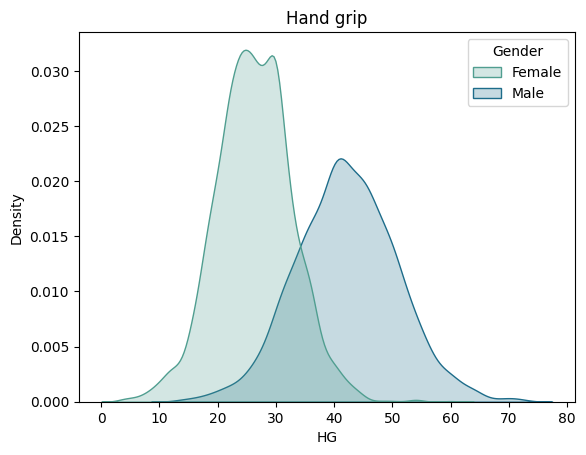

In [979]:
plt.figure()
sns.kdeplot(data = main_test, x= 'HG', hue = 'Gender', fill=True, palette = "crest")
plt.title("Hand grip")
plt.show()

## 2.6 Health

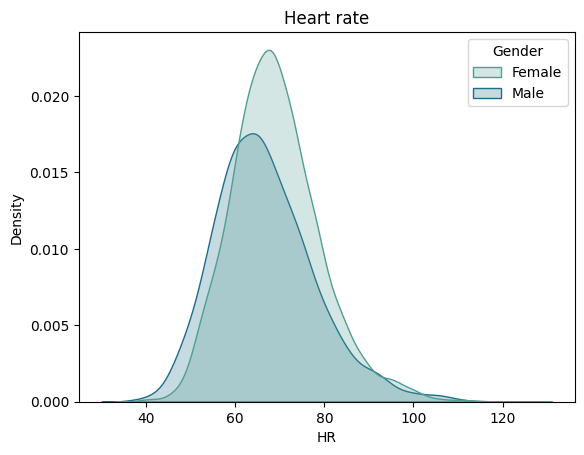

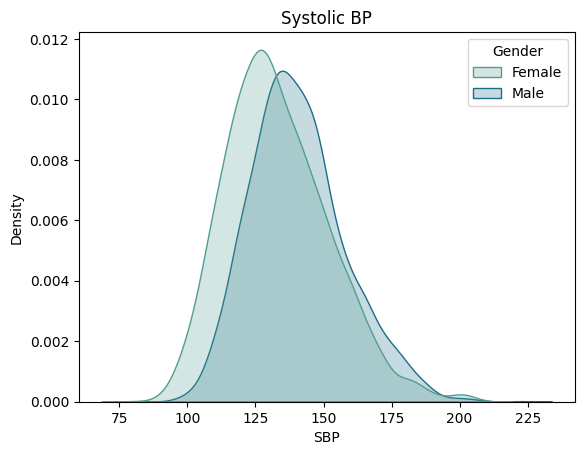

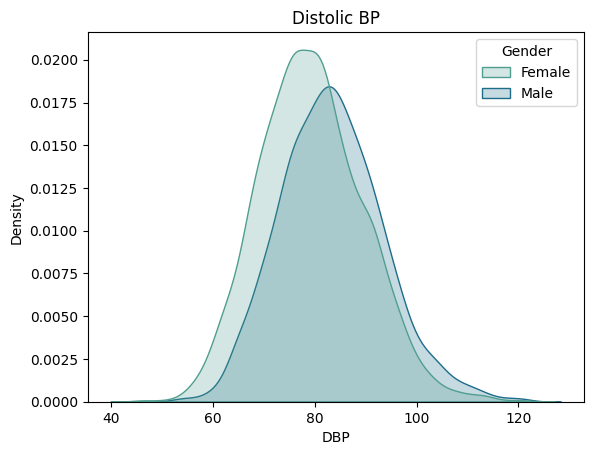

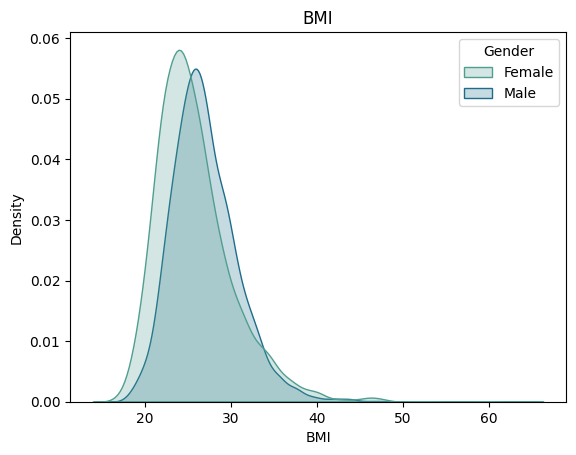

In [980]:
plt.figure()
sns.kdeplot(data = main_test, x= 'HR', hue = 'Gender', fill=True, palette = "crest")
plt.title("Heart rate")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'SBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Systolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'DBP', hue = 'Gender', fill=True, palette = "crest")
plt.title("Distolic BP")
plt.show()

plt.figure()
sns.kdeplot(data = main_test, x= 'BMI', hue = 'Gender', fill=True, palette = "crest")
plt.title("BMI")
plt.show()

## 2.7 Other variables

Job PA: Never/rarely            2903
Sometimes                545
Usually                  101
Always                    54
Prefer not to answer       1
Do not know                0
Name: JPA, dtype: int64


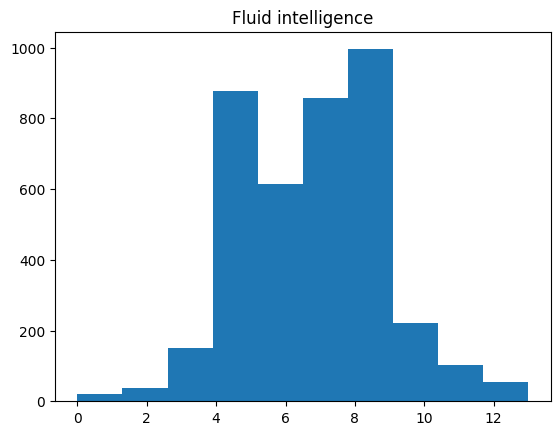

In [981]:
print("Job PA:", main_test["JPA"].value_counts())

plt.figure()
plt.hist(data = main_test, x= 'FI')
plt.title("Fluid intelligence")
plt.show()


# 3 Recode variables

In [982]:
# 1 = Cheadle;  2 = Reading;  3 = Newcastle;  4 = Bristol
main_test['IS'] = main_test['IS'].map({'11025': 1, '11026': 2,'11027': 3, '11028': 4})
main_test["Gender"] = main_test["Gender"].map({"Female":0, "Male":1})
main_test["Gender"] = main_test["Gender"].astype("int")
main_test["JPA"] = main_test["JPA"].map({"Never/rarely":0, "Sometimes":1, "Usually":2,"Always":3})

del main_test["ID"]
del main_test["BADDesikan"]
del main_test["BADASEG"]


main_test = main_test.rename(columns={"BADA2009": "BA"})

main_test = pd.DataFrame(main_test)
main_test = stats.zscore(main_test,nan_policy='omit')

# 4 Simple correlation heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'TPA'),
  Text(0, 3.5, 'VPA'),
  Text(0, 4.5, 'MPA'),
  Text(0, 5.5, 'MVPA'),
  Text(0, 6.5, 'LPA'),
  Text(0, 7.5, 'BMI'),
  Text(0, 8.5, 'SRLPA'),
  Text(0, 9.5, 'SRMPA'),
  Text(0, 10.5, 'SRVPA'),
  Text(0, 11.5, 'FI'),
  Text(0, 12.5, 'HG'),
  Text(0, 13.5, 'IS'),
  Text(0, 14.5, 'HR'),
  Text(0, 15.5, 'JPA'),
  Text(0, 16.5, 'DBP'),
  Text(0, 17.5, 'SBP'),
  Text(0, 18.5, 'BA')])

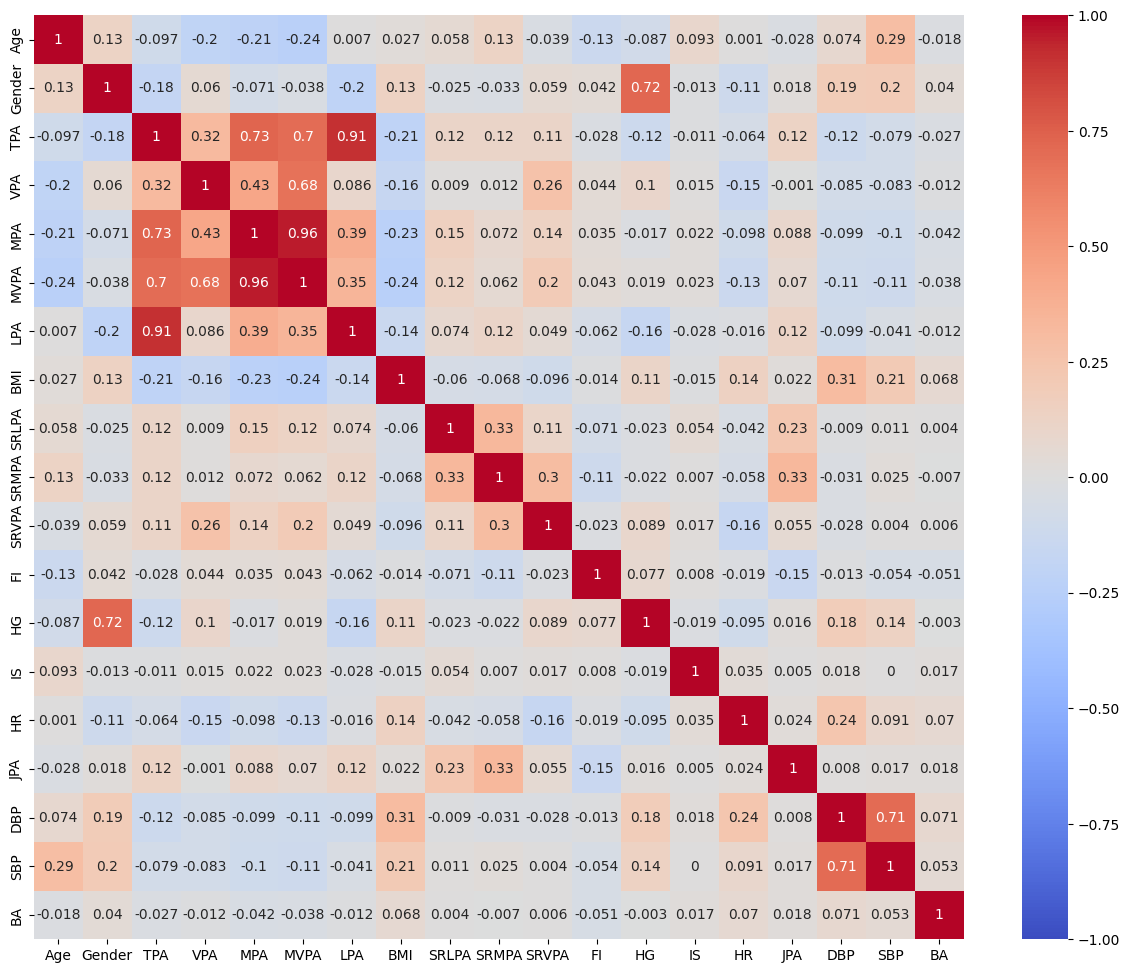

In [983]:
corr = main_test.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 5 Partial correlations with Covariates

In [984]:
cov_correlation = pg.partial_corr(data=main_test, x='SRLPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRMPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='SRVPA', y='BA', covar=["Gender", "IS", "Age"])
print("SR Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='TPA', y='BA', covar=["Gender", "IS", "Age"])
print("Total PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='LPA', y='BA', covar=["Gender", "IS", "Age"])
print("Light PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='VPA', y='BA', covar=["Gender", "IS", "Age"])
print("Vigorous PA")
print(cov_correlation)
cov_correlation = pg.partial_corr(data=main_test, x='MVPA', y='BA', covar=["Gender", "IS", "Age"])
print("Moderate+Vigorous PA")
print(cov_correlation)

SR Light PA
            n         r          CI95%     p-val
pearson  5422  0.005307  [-0.02, 0.03]  0.696081
SR Moderate PA
            n         r          CI95%     p-val
pearson  5422 -0.002243  [-0.03, 0.02]  0.868898
SR Vigorous PA
            n        r          CI95%     p-val
pearson  5422  0.00248  [-0.02, 0.03]  0.855182
Total PA
            n         r         CI95%     p-val
pearson  5422 -0.021851  [-0.05, 0.0]  0.107759
Light PA
            n         r          CI95%     p-val
pearson  5422 -0.002332  [-0.03, 0.02]  0.863713
Moderate PA
            n         r           CI95%     p-val
pearson  5422 -0.046276  [-0.07, -0.02]  0.000655
Vigorous PA
            n         r          CI95%     p-val
pearson  5422 -0.020533  [-0.05, 0.01]  0.130703
Moderate+Vigorous PA
            n         r           CI95%     p-val
pearson  5422 -0.044635  [-0.07, -0.02]  0.001014


# 6 Models OLS

## 6.1 Covariates

In [985]:
cov_model = ols('BA ~ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(cov_model.summary())

#calculate effect size
results = cov_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     5.967
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           3.16e-06
Time:                        14:14:12   Log-Likelihood:                -7675.6
No. Observations:                5422   AIC:                         1.537e+04
Df Residuals:                    5415   BIC:                         1.541e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0062      0.014     -0.453      0.6

## 6.2 Accelerometer PA

In [986]:
pa_model = ols('BA ~ LPA + MPA + VPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_model.summary())

#calculate effect size
results = pa_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     5.466
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           1.66e-07
Time:                        14:14:12   Log-Likelihood:                -7669.0
No. Observations:                5422   AIC:                         1.536e+04
Df Residuals:                    5412   BIC:                         1.542e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0061      0.014     -0.446      0.6

## 6.3 Self-report PA

In [987]:
sr_model = ols('BA ~ SRLPA + SRMPA + SRVPA +Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_model.summary())

#calculate effect size
results = sr_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     4.005
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           4.05e-05
Time:                        14:14:13   Log-Likelihood:                -7675.5
No. Observations:                5422   AIC:                         1.537e+04
Df Residuals:                    5412   BIC:                         1.544e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0062      0.014     -0.452      0.6

## 6.4 SR + Job PA + FI

In [988]:
sr_ex_model = ols('BA ~ SRLPA + SRMPA + SRVPA + FI + JPA + Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_ex_model.summary())

#calculate effect size
results = sr_ex_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(2589))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.105
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           0.000363
Time:                        14:14:13   Log-Likelihood:                -3640.0
No. Observations:                2589   AIC:                             7304.
Df Residuals:                    2577   BIC:                             7374.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0445      0.021     -2.080      0.0

## 6.5 Accelerometer + Self-report PA

In [989]:
sr_pa_model = ols('BA ~ SRLPA + SRMPA + SRVPA +LPA + MPA + VPA+ Gender + Age + IS + Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(sr_pa_model.summary())

#calculate effect size
results = sr_pa_model
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.200
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           1.28e-06
Time:                        14:14:13   Log-Likelihood:                -7668.3
No. Observations:                5422   AIC:                         1.536e+04
Df Residuals:                    5409   BIC:                         1.545e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0061      0.014     -0.442      0.6

## 6.6 PA + Fitness

In [990]:
pa_fitness = ols('BA ~ HG + LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_fitness.summary())

#calculate effect size
results = pa_fitness
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     6.546
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           3.86e-10
Time:                        14:14:13   Log-Likelihood:                -7660.9
No. Observations:                5422   AIC:                         1.534e+04
Df Residuals:                    5411   BIC:                         1.542e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0061      0.014     -0.445      0.6

## 6.7 Fitness

In [991]:
fitness = ols('BA ~ HG + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fitness.summary())

#calculate effect size
results = fitness
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     7.414
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           6.77e-09
Time:                        14:14:13   Log-Likelihood:                -7667.6
No. Observations:                5422   AIC:                         1.535e+04
Df Residuals:                    5414   BIC:                         1.540e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0062      0.014     -0.452      0.6

## 6.8 Health

In [992]:
health = ols('BA ~ SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(health.summary())

#calculate effect size
results = health
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     8.958
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           1.56e-13
Time:                        14:14:13   Log-Likelihood:                -7653.4
No. Observations:                5422   AIC:                         1.533e+04
Df Residuals:                    5412   BIC:                         1.539e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0067      0.014     -0.491      0.6

## 6.9 Health and Fitness

In [993]:
he_fi = ols('BA ~ HG + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(he_fi.summary())

#calculate effect size
results = he_fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     9.933
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           1.09e-16
Time:                        14:14:13   Log-Likelihood:                -7644.2
No. Observations:                5422   AIC:                         1.531e+04
Df Residuals:                    5411   BIC:                         1.538e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0067      0.014     -0.492      0.6

## 6.10 PA & Health

In [994]:
pa_he = ols('BA ~ LPA + MPA + VPA + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_he.summary())

#calculate effect size
results = pa_he
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     7.528
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           5.70e-14
Time:                        14:14:13   Log-Likelihood:                -7648.6
No. Observations:                5422   AIC:                         1.532e+04
Df Residuals:                    5409   BIC:                         1.541e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0066      0.014     -0.486      0.6

## 6.11 PA + Health + Fitness

In [995]:
pa_he_fi = ols('BA ~ LPA + MPA + VPA + HG + SBP + HR + DBP + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(pa_he_fi.summary())

#calculate effect size
results = pa_he_fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     8.413
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           3.87e-17
Time:                        14:14:14   Log-Likelihood:                -7639.2
No. Observations:                5422   AIC:                         1.531e+04
Df Residuals:                    5408   BIC:                         1.540e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0067      0.014     -0.488      0.6

## 6.12 Fluid intelligence

In [996]:
fi = ols('BA ~ FI + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fi.summary())

#calculate effect size
results = fi
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(3930))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     BA   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.457
Date:                Wed, 18 Jan 2023   Prob (F-statistic):           5.96e-05
Time:                        14:14:14   Log-Likelihood:                -5548.2
No. Observations:                3930   AIC:                         1.111e+04
Df Residuals:                    3922   BIC:                         1.116e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0125      0.016     -0.781      0.4

## 6.13 Fitness models

In [997]:
fit = ols('HG ~ LPA + MPA + VPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit.summary())

#calculate effect size
results = fit
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     750.9
Date:                Wed, 18 Jan 2023   Prob (F-statistic):               0.00
Time:                        14:14:14   Log-Likelihood:                -5496.6
No. Observations:                5422   AIC:                         1.101e+04
Df Residuals:                    5412   BIC:                         1.108e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0003      0.009      0.029      0.9

In [998]:
fit2 = ols('HG ~ LPA + MPA + VPA + SRLPA + SRMPA + SRVPA + Age + Gender + IS+ Gender:Age + Gender:IS + Age:IS', missing='drop', data = main_test).fit()
print(fit2.summary())

#calculate effect size
results = fit2
coefficients = results.params
stderr = results.bse
effect_size = coefficients / (stderr* np.sqrt(5422))
print(effect_size)

                            OLS Regression Results                            
Dep. Variable:                     HG   R-squared:                       0.557
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     566.3
Date:                Wed, 18 Jan 2023   Prob (F-statistic):               0.00
Time:                        14:14:14   Log-Likelihood:                -5487.3
No. Observations:                5422   AIC:                         1.100e+04
Df Residuals:                    5409   BIC:                         1.109e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0002      0.009      0.024      0.9

# 7 Model comparisons

## 7.1 Cov x PA

In [999]:
model_comparison = anova_lm(cov_model, pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    5415.0  5386.388256      0.0        NaN       NaN       NaN
1    5412.0  5373.157413      3.0  13.230844  4.442163  0.004009


In [1000]:
model_comparison = anova_lm(cov_model, sr_model)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F  Pr(>F)
0    5415.0  5386.388256      0.0       NaN       NaN     NaN
1    5412.0  5386.130818      3.0  0.257438  0.086225  0.9676


## 7.2 Cov x PA x SR

In [1001]:
model_comparison = anova_lm(pa_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F    Pr(>F)
0    5412.0  5373.157413      0.0       NaN       NaN       NaN
1    5409.0  5371.941067      3.0  1.216345  0.408245  0.747084


In [1002]:
model_comparison = anova_lm(sr_model, sr_pa_model)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F   Pr(>F)
0    5412.0  5386.130818      0.0        NaN       NaN      NaN
1    5409.0  5371.941067      3.0  14.189751  4.762547  0.00256


## 7.3 SR x Job + FI

In [1003]:
model_comparison = anova_lm(sr_model, sr_ex_model)
print(model_comparison)

   df_resid          ssr  df_diff      ss_diff         F    Pr(>F)
0    5412.0  5386.130818      0.0          NaN       NaN       NaN
1    2577.0  2522.575965   2835.0  2863.554853  1.031864  0.207818


## 7.4 Fitness models

In [1004]:
model_comparison = anova_lm(fit, fit2)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff        F    Pr(>F)
0    5412.0  2411.192120      0.0       NaN      NaN       NaN
1    5409.0  2402.905707      3.0  8.286413  6.21764  0.000327


## 7.5 Health x Fitness x PA

In [1005]:
model_comparison = anova_lm(pa_model, pa_fitness)
print(model_comparison)

   df_resid          ssr  df_diff   ss_diff         F   Pr(>F)
0    5412.0  5373.157413      0.0       NaN       NaN      NaN
1    5411.0  5357.193372      1.0  15.96404  16.12438  0.00006


In [1006]:
model_comparison = anova_lm(pa_model, pa_he)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff         F        Pr(>F)
0    5412.0  5373.157413      0.0        NaN       NaN           NaN
1    5409.0  5332.928967      3.0  40.228446  13.60076  7.746982e-09


In [1007]:
model_comparison = anova_lm(pa_model, pa_he_fi)
print(model_comparison)

   df_resid          ssr  df_diff    ss_diff          F        Pr(>F)
0    5412.0  5373.157413      0.0        NaN        NaN           NaN
1    5408.0  5314.526643      4.0  58.630769  14.915496  3.980016e-12


# 8 Mediation analysis

## 8.1 PA x Health / Fitness

### 8.1.1 BMI

In [1008]:
#regression of x on m
model1 = ols('BMI ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()

indirect_effect = (model1.params["LPA"] / (model1.bse["LPA"]* np.sqrt(5422)))*(model2.params["BMI"] / (model2.bse["BMI"]* np.sqrt(5422)))
total_effect = model3.params["LPA"] / (model3.bse["LPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.009439202030555212
Direct effect:  -0.002508342821149704
Total effect:  -0.011947544851704916


In [1009]:
#regression of x on m
model1 = ols('BMI ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["MPA"] / (model1.bse["MPA"]* np.sqrt(5422)))*(model2.params["BMI"] / (model2.bse["BMI"]* np.sqrt(5422)))
total_effect = model3.params["MPA"] / (model3.bse["MPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.01643019586663851
Direct effect:  -0.025789832513208138
Total effect:  -0.04222002837984665


In [1010]:
#regression of x on m
model1 = ols('BMI ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ BMI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["VPA"] / (model1.bse["VPA"]* np.sqrt(5422)))*(model2.params["BMI"] / (model2.bse["BMI"]* np.sqrt(5422)))
total_effect = model3.params["VPA"] / (model3.bse["VPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.011282739265467467
Direct effect:  -0.0006998651133496049
Total effect:  -0.011982604378817072


### 8.1.2 DBP

In [1011]:
#regression of x on m
model1 = ols('DBP ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["LPA"] / (model1.bse["LPA"]* np.sqrt(5422)))*(model2.params["DBP"] / (model2.bse["DBP"]* np.sqrt(5422)))
total_effect = model3.params["LPA"] / (model3.bse["LPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.007113619042463901
Direct effect:  -0.004833925809241015
Total effect:  -0.011947544851704916


In [1012]:
#regression of x on m
model1 = ols('DBP ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["MPA"] / (model1.bse["MPA"]* np.sqrt(5422)))*(model2.params["DBP"] / (model2.bse["DBP"]* np.sqrt(5422)))
total_effect = model3.params["MPA"] / (model3.bse["MPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.007137335981987222
Direct effect:  -0.035082692397859425
Total effect:  -0.04222002837984665


In [1013]:
#regression of x on m
model1 = ols('DBP ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ DBP',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["VPA"] / (model1.bse["VPA"]* np.sqrt(5422)))*(model2.params["DBP"] / (model2.bse["DBP"]* np.sqrt(5422)))
total_effect = model3.params["VPA"] / (model3.bse["VPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.006072363150618375
Direct effect:  -0.005910241228198697
Total effect:  -0.011982604378817072


### 8.1.3 Heart rate

In [1014]:
#regression of x on m
model1 = ols('HR ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["LPA"] / (model1.bse["LPA"]* np.sqrt(5422)))*(model2.params["HR"] / (model2.bse["HR"]* np.sqrt(5422)))
total_effect = model3.params["LPA"] / (model3.bse["LPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.0011506173051034094
Direct effect:  -0.010796927546601507
Total effect:  -0.011947544851704916


In [1015]:
#regression of x on m
model1 = ols('HR ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["MPA"] / (model1.bse["MPA"]* np.sqrt(5422)))*(model2.params["HR"] / (model2.bse["HR"]* np.sqrt(5422)))
total_effect = model3.params["MPA"] / (model3.bse["MPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.006903732381918681
Direct effect:  -0.03531629599792797
Total effect:  -0.04222002837984665


In [1016]:
#regression of x on m
model1 = ols('HR ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HR',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["VPA"] / (model1.bse["VPA"]* np.sqrt(5422)))*(model2.params["HR"] / (model2.bse["HR"]* np.sqrt(5422)))
total_effect = model3.params["VPA"] / (model3.bse["VPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.010483909620241727
Direct effect:  -0.001498694758575345
Total effect:  -0.011982604378817072


### 8.1.4 Hand grip

In [1017]:
#regression of x on m
model1 = ols('HG ~ LPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ LPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["LPA"] / (model1.bse["LPA"]* np.sqrt(5422)))*(model2.params["HG"] / (model2.bse["HG"]* np.sqrt(5422)))
total_effect = model3.params["LPA"] / (model3.bse["LPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 0.0004554019484185372
Direct effect:  -0.012402946800123453
Total effect:  -0.011947544851704916


In [1018]:
#regression of x on m
model1 = ols('HG ~ MPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ MPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["MPA"] / (model1.bse["MPA"]* np.sqrt(5422)))*(model2.params["HG"] / (model2.bse["HG"]* np.sqrt(5422)))
total_effect = model3.params["MPA"] / (model3.bse["MPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 4.670099856455823e-05
Direct effect:  -0.04226672937841121
Total effect:  -0.04222002837984665


In [1019]:
#regression of x on m
model1 = ols('HG ~ VPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ HG',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ VPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["VPA"] / (model1.bse["VPA"]* np.sqrt(5422)))*(model2.params["HG"] / (model2.bse["HG"]* np.sqrt(5422)))
total_effect = model3.params["VPA"] / (model3.bse["VPA"]* np.sqrt(5422))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: -0.00028466265330269187
Direct effect:  -0.011697941725514381
Total effect:  -0.011982604378817072


## 8.2 SR PA x Job PA / Fluid intelligence

In [1020]:
#regression of x on m
model1 = ols('FI ~ SRLPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRLPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["SRLPA"] / (model1.bse["SRLPA"]* np.sqrt(3930)))*(model2.params["FI"] / (model2.bse["FI"]* np.sqrt(3930)))
total_effect = model3.params["SRLPA"] / (model3.bse["SRLPA"]* np.sqrt(3930))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 0.0036080066525127023
Direct effect:  0.0008134769961829812
Total effect:  0.0044214836486956835


In [1021]:
#regression of x on m
model1 = ols('FI ~ SRMPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRMPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["SRMPA"] / (model1.bse["SRMPA"]* np.sqrt(3930)))*(model2.params["FI"] / (model2.bse["FI"]* np.sqrt(3930)))
total_effect = model3.params["SRMPA"] / (model3.bse["SRMPA"]* np.sqrt(3930))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 0.005814335655433158
Direct effect:  -0.013963354755829249
Total effect:  -0.008149019100396091


In [1022]:
#regression of x on m
model1 = ols('FI ~ SRVPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ SRVPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["SRVPA"] / (model1.bse["SRVPA"]* np.sqrt(3930)))*(model2.params["FI"] / (model2.bse["FI"]* np.sqrt(3930)))
total_effect = model3.params["SRVPA"] / (model3.bse["SRVPA"]* np.sqrt(3930))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 0.001167753128251543
Direct effect:  0.006322414029386523
Total effect:  0.007490167157638066


In [1023]:
#regression of x on m
model1 = ols('FI ~ JPA', data = main_test).fit()
#regression of y on m
model2 = ols('BA ~ FI',data = main_test).fit()
#regression of y on x
model3 = ols('BA ~ JPA', data = main_test).fit()
#calculate the indirect effect
indirect_effect = (model1.params["JPA"] / (model1.bse["JPA"]* np.sqrt(2589)))*(model2.params["FI"] / (model2.bse["FI"]* np.sqrt(2589)))
total_effect = model3.params["JPA"] / (model3.bse["JPA"]* np.sqrt(2589))
direct_effect = total_effect - indirect_effect

#print the results
print("Indirect effect:",indirect_effect)
print('Direct effect: ',direct_effect)
print('Total effect: ',total_effect)

Indirect effect: 0.009301470479965296
Direct effect:  0.011681057493850948
Total effect:  0.020982527973816244


# 9 LASSO Regression

<Figure size 1200x900 with 0 Axes>

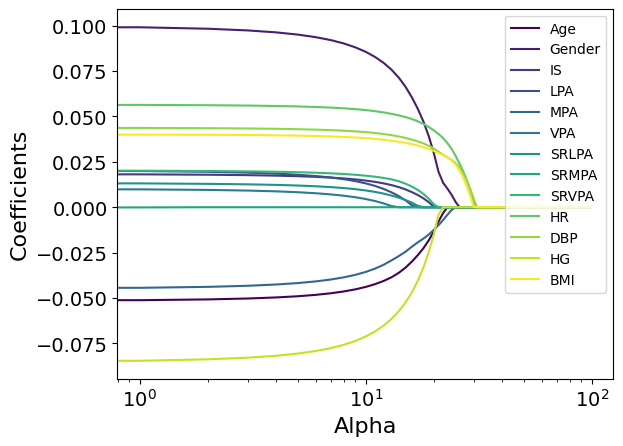

In [1024]:
df = main_test[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI", "BA"]]
df = df.dropna()
df = pd.DataFrame(df)
X = df[["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI"]]
Y = df["BA"]
columns = ["Age", "Gender", "IS", "LPA", "MPA", "VPA",  "SRLPA", "SRMPA", "SRVPA", "HR", "DBP", "HG", "BMI"]

coefs = []
alphas = np.power(10,np.linspace(start=-3, stop=3, num=100))

for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X,Y)
    coefs.append(lasso.coef_)

coefs = pd.DataFrame(coefs)
coefs.columns = columns
coefs = pd.DataFrame(coefs)


cmap = cm.get_cmap('viridis')
plt.figure(figsize=(12,9))
coefs.plot(kind='line', colormap=cmap)
#plt.plot(coefs, color=cm.plasma([np.linspace(0,1,12)]))

plt.xticks(alphas, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xscale("log")
plt.axis('tight')
plt.xlabel('Alpha', fontsize = 16)
plt.ylabel('Coefficients', fontsize = 16)
#plt.title('Lasso coefficients as a function of alpha')
plt.legend(columns, loc="upper right")
plt.show()

# 10 Figures for Paper

## 10.1 Smaller Correlation Heatmap

(array([ 0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5, 10.5,
        11.5, 12.5, 13.5, 14.5, 15.5]),
 [Text(0, 0.5, 'Age'),
  Text(0, 1.5, 'Gender'),
  Text(0, 2.5, 'VPA'),
  Text(0, 3.5, 'MPA'),
  Text(0, 4.5, 'LPA'),
  Text(0, 5.5, 'BMI'),
  Text(0, 6.5, 'SRLPA'),
  Text(0, 7.5, 'SRMPA'),
  Text(0, 8.5, 'SRVPA'),
  Text(0, 9.5, 'FI'),
  Text(0, 10.5, 'HG'),
  Text(0, 11.5, 'HR'),
  Text(0, 12.5, 'JPA'),
  Text(0, 13.5, 'DBP'),
  Text(0, 14.5, 'SBP'),
  Text(0, 15.5, 'BA')])

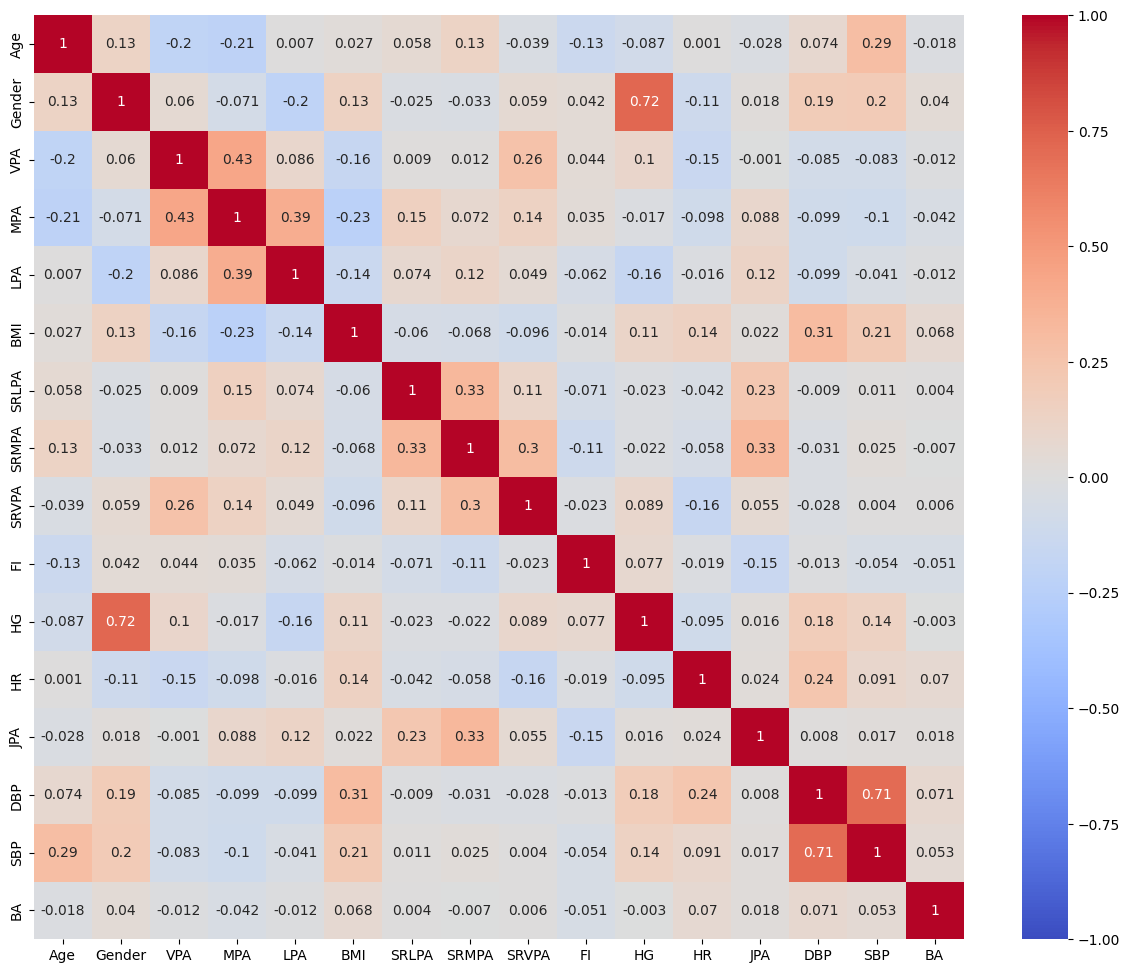

In [1025]:
x = main_test
# del x["SBP"]
del x["TPA"]
del x["MVPA"]
del x["IS"]
#del x["JPA"]
corr = x.corr()
corr = round(corr,3)
fig, ax = plt.subplots(figsize=(15,12)) 
sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax=1)
plt.xticks(size=10)
plt.yticks(size=10)

# 11 Exploration vs. Validation

## 11.1 Import processed Validation set

In [1026]:
validate = pd.read_pickle("3_validate.pkl")
validate = pd.DataFrame(validate)

## 11.2 BrainAGE distribution

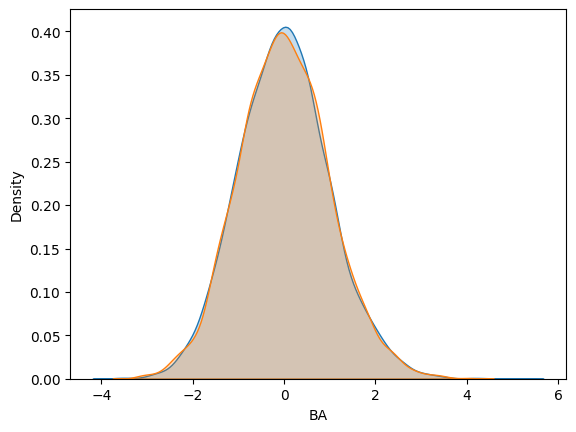

In [1027]:
plt.figure()
sns.kdeplot(data = validate, x= 'BA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'BA', fill=True, label = "Explore")
plt.show()

## 11.3 MPA distribution

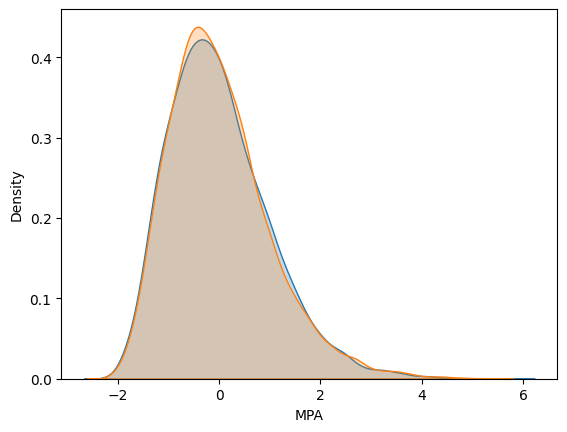

In [1028]:
plt.figure()
sns.kdeplot(data = validate, x= 'MPA', fill=True, label = "Validate")
sns.kdeplot(data = main_test, x= 'MPA', fill=True, label = "Explore")
plt.show()